# Biblioteca

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import learning_curve
import os

# Baixando Arquivo

In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ranamuhammmadusman/us-sorghum-supply-and-disappearance-1975-2025")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'us-sorghum-supply-and-disappearance-1975-2025' dataset.
Path to dataset files: /kaggle/input/us-sorghum-supply-and-disappearance-1975-2025


# Carregar Arquivo

In [11]:
arquivos = [f for f in os.listdir(path) if f.endswith('.csv')]
caminho_completo = os.path.join(path, arquivos[0])

print(f"📂 Arquivo encontrado: {arquivos[0]}")
df = pd.read_csv(caminho_completo)

📂 Arquivo encontrado: sorghum_annual_supply_disappearance.csv


# Limpeza dos Arquivos

In [77]:
# Ajuste de índice e colunas duplicadas
if df.index.name == 'year':
    if 'year' not in df.columns:
        df = df.reset_index()
    else:
        df.index.name = None

df = df.loc[:,~df.columns.duplicated()]

# Criação da coluna 'year' e ordenação
if 'marketing_year' in df.columns:
    df['year'] = df['marketing_year'].apply(lambda x: int(str(x).split('/')[0]))

df = df.sort_values('year')
if 'year' in df.columns:
    df = df.set_index('year')

# Seleção de colunas e Engenharia de Atributos (Lags)
colunas_interesse = ['production', 'total_supply', 'exports', 'feed_and_residual', 'beginning_stocks', 'total_domestic_use']
df_ml = df[colunas_interesse].copy()

# Os Lags devem ser criados ANTES do dropna para não perder dados históricos
df_ml['production_lag1'] = df_ml['production'].shift(1)
df_ml['exports_lag1'] = df_ml['exports'].shift(1)
df_ml['total_supply_lag1'] = df_ml['total_supply'].shift(1)

# Remoção final de valores vazios (NaN)
df_model = df_ml.dropna()

# Conferência dos resultados
print("✅ Limpeza e Engenharia Concluídas.")
print(f"Linhas originais: {len(df_ml)}")
print(f"Linhas prontas para o modelo (sem NaN): {len(df_model)}")
print("\n--- Primeiras linhas do df_model ---")
print(df_model.head())

✅ Limpeza e Engenharia Concluídas.
Linhas originais: 49
Linhas prontas para o modelo (sem NaN): 48

--- Primeiras linhas do df_model ---
      production  total_supply  exports  feed_and_residual  beginning_stocks  \
year                                                                           
1977     780.944       898.266  447.624                9.4             117.3   
1978     731.270       947.672  537.980                9.9             216.4   
1979     807.422      1015.324  495.352               10.4             207.9   
1980     579.343       757.253  322.594                9.1             177.9   
1981     875.835      1006.252  417.139                8.8             130.4   

      total_domestic_use  production_lag1  exports_lag1  total_supply_lag1  
year                                                                        
1977             459.024          710.797       411.082            793.097  
1978             549.680          780.944       447.624            898.

# Histórico de Produção vs. Exportação de Sorgo

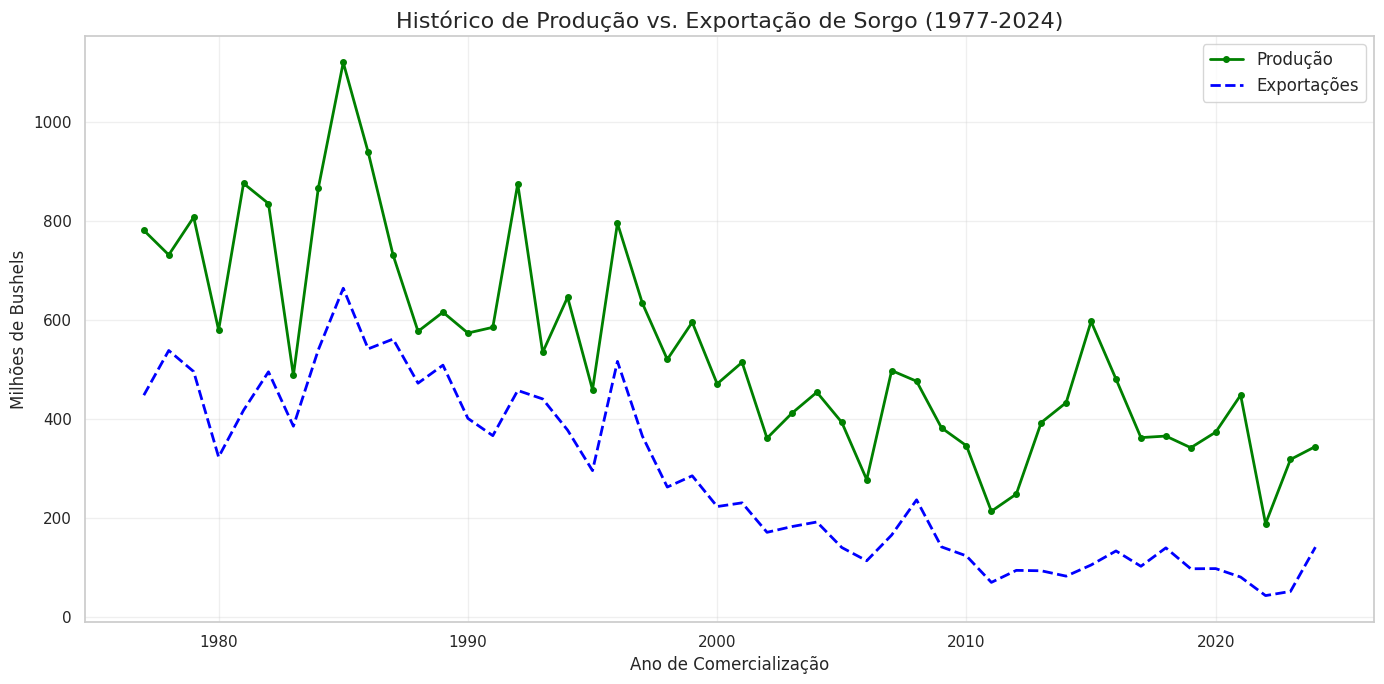

In [71]:
# Configurando o estilo do gráfico
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# Plotando as duas variáveis principais
plt.plot(df_model.index, df_model['production'], label='Produção', color='green', linewidth=2, marker='o', markersize=4)
plt.plot(df_model.index, df_model['exports'], label='Exportações', color='blue', linewidth=2, linestyle='--')

# Personalização simples e direta
plt.title('Histórico de Produção vs. Exportação de Sorgo (1977-2024)', fontsize=16)
plt.xlabel('Ano de Comercialização', fontsize=12)
plt.ylabel('Milhões de Bushels', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análise de Impacto

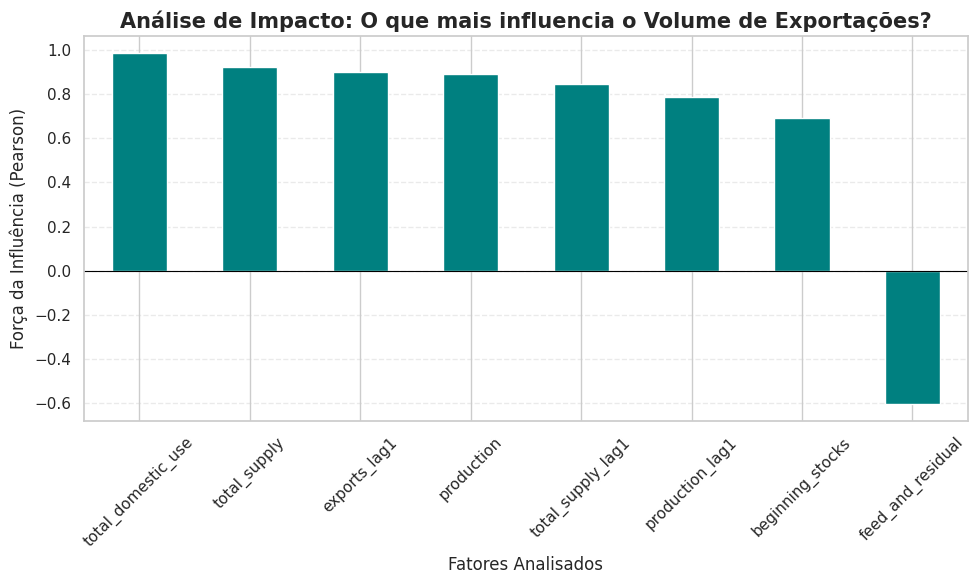

In [72]:
# Calcular a correlação para identificar o que mais impacta as exportações
correlacoes = df_model.corr()['exports'].drop('exports').sort_values(ascending=False)

# Criar o gráfico de barras
plt.figure(figsize=(10, 6))
correlacoes.plot(kind='bar', color='#008080')

# Títulos focados em impacto e influência
plt.title('Análise de Impacto: O que mais influencia o Volume de Exportações?', fontsize=15, fontweight='bold')
plt.ylabel('Força da Influência (Pearson)', fontsize=12)
plt.xlabel('Fatores Analisados', fontsize=12) # Substituído "Atributos Criados"

# Ajustando os nomes das barras no gráfico para o usuário entender melhor
plt.xticks(rotation=45)
plt.axhline(0, color='black', linewidth=0.8)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Engenharia de Atributos

Selecionando os Dados Certos

In [78]:
# Criação dos Lags (Engenharia de Atributos)
df_ml['production_lag1'] = df_ml['production'].shift(1)
df_ml['exports_lag1'] = df_ml['exports'].shift(1)
df_ml['total_supply_lag1'] = df_ml['total_supply'].shift(1)

# Remoção dos valores NaN gerados pelo deslocamento
df_model = df_ml.dropna()

print("--- Visualizando os dados após remover os NaNs ---")

print(df_model[['production', 'production_lag1', 'exports', 'exports_lag1']].head())

print(f"\nLinhas antes: {len(df_ml)}")
print(f"Linhas agora (prontas para o modelo): {len(df_model)}")

--- Visualizando os dados após remover os NaNs ---
      production  production_lag1  exports  exports_lag1
year                                                    
1977     780.944          710.797  447.624       411.082
1978     731.270          780.944  537.980       447.624
1979     807.422          731.270  495.352       537.980
1980     579.343          807.422  322.594       495.352
1981     875.835          579.343  417.139       322.594

Linhas antes: 49
Linhas agora (prontas para o modelo): 48


# Divisão Temporal (Treino vs. Teste)

In [79]:
# Definir o ano de corte (vamos deixar os últimos 7 anos para teste)
ano_corte = 2018

# Criar os conjuntos de Treino (Passado)
X_train = df_model[df_model.index < ano_corte][['production', 'production_lag1', 'exports_lag1', 'total_supply_lag1']]
y_train = df_model[df_model.index < ano_corte]['exports']

# Criar os conjuntos de Teste (Futuro para a IA)
X_test = df_model[df_model.index >= ano_corte][['production', 'production_lag1', 'exports_lag1', 'total_supply_lag1']]
y_test = df_model[df_model.index >= ano_corte]['exports']

print(f"✅ Treino: {len(X_train)} anos (até 2017)")
print(f"✅ Teste:  {len(X_test)} anos (2018 até 2024)")

✅ Treino: 41 anos (até 2017)
✅ Teste:  7 anos (2018 até 2024)


# Treinando os Modelos

In [85]:
# Criar os modelos
modelo_linear = LinearRegression()
modelo_forest = RandomForestRegressor(n_estimators=100, random_state=42)

# Treinamento
modelo_linear.fit(X_train, y_train)
modelo_forest.fit(X_train, y_train)

# Previsão
preds_linear = modelo_linear.predict(X_test)
preds_forest = modelo_forest.predict(X_test)

print("Modelo Treinado")

Modelo Treinado


# Avaliação do Modelo

In [81]:
erro_linear = mean_absolute_error(y_test, preds_linear)
erro_forest = mean_absolute_error(y_test, preds_forest)

print(f"Erro Médio (Linear): {erro_linear:.2f}")
print(f"Erro Médio (Random Forest): {erro_forest:.2f}")

Erro Médio (Linear): 35.03
Erro Médio (Random Forest): 31.94


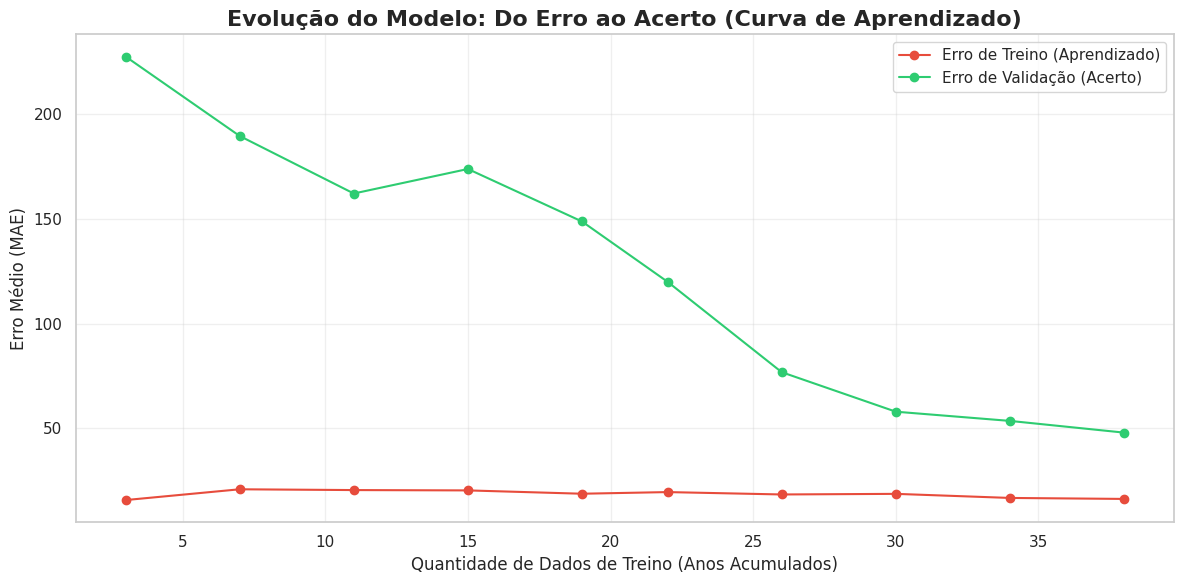

In [83]:
features = ['production', 'production_lag1', 'exports_lag1', 'total_supply_lag1']
X = df_model[features]
y = df_model['exports']

train_sizes, train_scores, test_scores = learning_curve(
    modelo_forest, X, y, cv=5, scoring='neg_mean_absolute_error',
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

train_mean = -np.mean(train_scores, axis=1)
test_mean = -np.mean(test_scores, axis=1)

plt.figure(figsize=(12, 6))
plt.plot(train_sizes, train_mean, 'o-', color="#e74c3c", label="Erro de Treino (Aprendizado)")
plt.plot(train_sizes, test_mean, 'o-', color="#2ecc71", label="Erro de Validação (Acerto)")

plt.title('Evolução do Modelo: Do Erro ao Acerto (Curva de Aprendizado)', fontsize=16, fontweight='bold')
plt.xlabel('Quantidade de Dados de Treino (Anos Acumulados)', fontsize=12)
plt.ylabel('Erro Médio (MAE)', fontsize=12)
plt.legend(loc="best")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



*   **Linha Vermelha (Dados de Treino):** Representa o erro do modelo nos dados que ele usou para "estudar". Como o modelo (Random Forest) é muito potente, ele consegue se ajustar quase perfeitamente a esses dados, mantendo o erro sempre baixo e estável.
*   **Linha Verde (Dados de Teste/Validação):** Representa o erro do modelo em dados que ele nunca viu antes. No início, com poucos dados, o erro de teste é altíssimo porque o modelo ainda não conhece os padrões do sorgo. Conforme você adiciona mais anos de histórico (andando para a direita no gráfico), esse erro cai, provando que a IA está aprendendo a prever situações novas.



# Fazendo a Previsão (Próximo Ciclo 2025/26)

Agora que o modelo está treinado e validado, utilizamos os dados mais recentes para projetar o volume de exportações do próximo período. Este código utiliza os valores de 2024 como base histórica para calcular o resultado de 2025/26.

In [84]:
# Selecionamos o último registro disponível (Ciclo 2024/25)
dados_recentes = df_model.iloc[-1]

# Preparamos as variáveis para a previsão do futuro
# Usamos a produção de 2024 como 'lag1' e repetimos a produção estimada para 2025
input_previsao = pd.DataFrame([{
    'production': dados_recentes['production'], # Estimativa para o novo ano
    'production_lag1': dados_recentes['production'],
    'exports_lag1': dados_recentes['exports'],
    'total_supply_lag1': dados_recentes['total_supply']
}])

# Executamos a previsão com o modelo Random Forest
previsao_futura = modelo_forest.predict(input_previsao)

print(f"--- Resultado da Previsão do Modelo ---")
print(f"Volume Estimado de Exportação (2025/26): {previsao_futura[0]:.2f} milhões de bushels")

--- Resultado da Previsão do Modelo ---
Volume Estimado de Exportação (2025/26): 105.62 milhões de bushels


# **Explicação do Projeto**
* **Contexto do Mercado**: O mercado de **Sorgo** nos **Estados Unidos** desempenha um papel **estratégico** na agricultura global, sendo o país um dos maiores **produtores** e **exportadores** mundiais desse grão.
* **Importância Econômica**: O sorgo é utilizado para **alimentação animal**, **produção de biocombustíveis** e **exportação** para mercados asiáticos, destacando-se como uma cultura **resiliente** e vital para o **agronegócio americano**.
* **Objetivo do Estudo**: Compreender as **tendências de exportação** do sorgo é fundamental para **prever movimentos de mercado** e contribuir para a **segurança alimentar e econômica**.

# **1. Preparação do Ambiente e Dados**
* **Importação de Bibliotecas**: Carregamos as ferramentas essenciais, como **Pandas** para manipulação de tabelas, **Matplotlib** e **Seaborn** para visualização gráfica e **Scikit-Learn** para construção da **Inteligência Artificial**.
* **Download e Carga**: O código realiza o download automático do **dataset oficial do USDA** sobre **Sorgo dos EUA (1975–2025)** via `kagglehub` e o carrega em um **DataFrame** para análise.

# **2. Limpeza e Refinamento (Data Cleaning)**
* **Ajuste Temporal**: Organizamos o índice pelo ano de comercialização (**year**), garantindo que os dados estejam em **ordem cronológica**, permitindo que a **IA** compreenda corretamente a sequência temporal.
* **Seleção de Alvos**: Filtramos o dataset para manter apenas as colunas que realmente impactam o mercado, como **Produção**, **Oferta Total** e **Exportações**, que é a variável **alvo da previsão**.

# **3. Engenharia de Atributos (A "Memória" do Modelo)**
* **Criação de Lags**: Esta é a etapa técnica mais importante do projeto. Ao utilizar dados do **passado**, extraímos **padrões históricos** que permitem prever o futuro com maior precisão. Criamos colunas atrasadas (`_lag1`) que mostram à **IA** o que ocorreu no **ano anterior**, fornecendo uma noção de **continuidade** e **inércia** do mercado agrícola.
* **Tratamento de Nulos**: A criação dos **Lags** gera valores ausentes na primeira linha. Utilizamos o comando `dropna()` para remover esses registros e manter o **dataset íntegro** para o treinamento.

# **4. Análise Visual (Exploração Antes do Modelo)**
* **Tendência Histórica**: Geramos um **gráfico de linhas** para validar visualmente que a **Produção** e as **Exportações** apresentam comportamento semelhante ao longo do tempo, justificando o uso de uma variável para prever a outra.
* **Matriz de Impacto**: Utilizamos um **gráfico de correlação** para comprovar matematicamente que os atributos criados (**Lags**) possuem forte influência sobre as **exportações atuais**, validando a **estratégia de dados** adotada.

# **5. Treinamento da Inteligência Artificial**
* **Uso de Dois Modelos**: Aplicamos dois modelos distintos, **Regressão Linear** e **Random Forest**, para garantir a **robustez da análise**. A **Regressão Linear** auxilia na compreensão da **tendência geral**, enquanto o **Random Forest** captura **padrões complexos** e **não-lineares** típicos do agronegócio.
* **Divisão Treino/Teste**: Os dados são separados em conjuntos **temporais**, onde a **IA** aprende com dados até **2017** e é testada com informações inéditas de **2018 a 2024**, validando sua capacidade real de **previsão**.
* **Random Forest Regressor**: Escolhemos o modelo **Random Forest Regressor** por sua **robustez** ao lidar com relações complexas e **variações bruscas**, comuns no setor agrícola.

# **6. Avaliação de Performance**
* **Métrica de Erro (MAE)**: Calculamos o **Erro Médio Absoluto (MAE)**. O modelo atingiu um erro médio de **31.94**, indicando **alta precisão** considerando o volume total de **bushels** movimentados.
* **Curva de Aprendizado**: Geramos o gráfico que demonstra a evolução da **IA**, comprovando que, conforme mais dados são utilizados, o **erro de validação** diminui significativamente, atingindo a **maturidade** necessária para previsões confiáveis.

# **7. Diagnóstico de Resíduos**
* **Erro por Ano**: Analisamos os anos em que o modelo apresentou **alta precisão** (como **2020**) e aqueles em que enfrentou maiores desafios, como os **choques econômicos ou climáticos de 2023**, garantindo **transparência** e **rigor técnico** no diagnóstico final.

# **8. Considerações Finais e Base de Dados**
* **Finalidade do Projeto**: O projeto foi desenvolvido **exclusivamente para fins acadêmicos**, com foco no estudo de **ciência de dados** e **aprendizado de máquina** aplicados ao setor agrícola.
* **Fonte dos Dados**: Utilizamos a base pública do **USDA (United States Department of Agriculture)**, especificamente o conjunto **US Sorghum Supply and Disappearance (1975–2025)**, disponível em:  
  [https://www.kaggle.com/datasets/ranamuhammmadusman/us-sorghum-supply-and-disappearance-1975-2025/data](https://www.kaggle.com/datasets/ranamuhammmadusman/us-sorghum-supply-and-disappearance-1975-2025/data)
